In [1]:
from __future__ import print_function
import datetime as dt
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [15]:
import math

Simulation finished with 56 events.
Arrival Times: [0.10792117 0.36274622 0.36276909 0.43477165 0.46651356 0.48589034
 0.52711327 0.61190856 0.71299907 0.86779103 0.9764589  1.20763484
 1.25337972 1.67431918 1.67987311 1.90188917 2.00990738 2.17350884
 2.20376343 2.24791807 2.57055161 3.26059705 3.33580478 3.57154548
 3.98966887 4.43968004 4.45745595 4.46542353 4.50264858 4.92362918
 4.94433425 5.05366199 5.68715377 5.83950977 6.07496109 6.15077898
 6.38277076 6.7426795  6.74637102 7.02374537 7.92320753 8.19900429
 8.26482847 8.57627284 8.59806312 8.71686599 9.19535811 9.26487685
 9.33274922 9.3606082  9.36451959 9.59167998 9.63923705 9.70096282
 9.8362496  9.84721742]


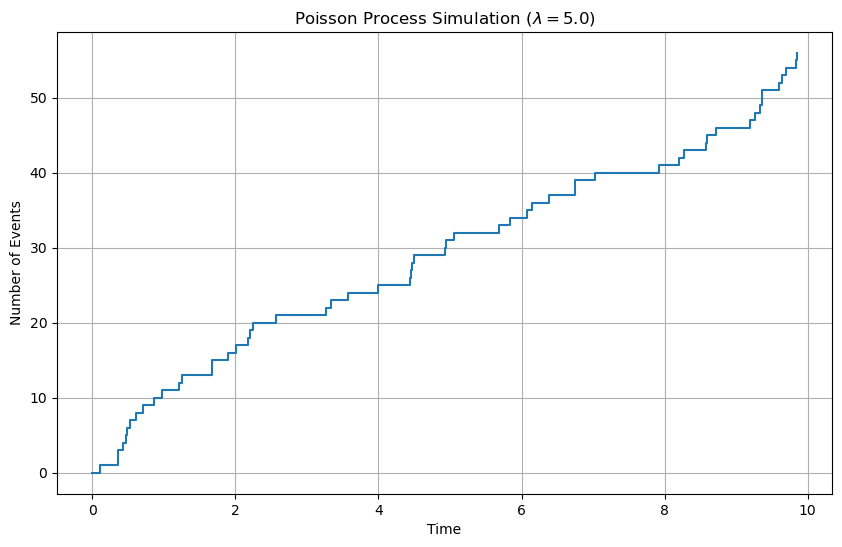

In [26]:
def simulate_poisson_process(rate, total_time, seed=None):
    """
    Simulates a homogeneous Poisson process.
    
    Parameters:
    - rate (float): Average events per unit time (lambda).
    - total_time (float): Total duration of simulation.
    - seed (int): Random seed for reproducibility.
    
    Returns:
    - times (array): Event times.
    - counts (array): Cumulative number of events.
    """
    if seed:
        np.random.seed(seed)
        
    # 1. Generate inter-arrival times using Exponential distribution (1/rate)
    # We generate more than needed to ensure we cover the total_time
    inter_arrival_times = np.random.exponential(1.0 / rate, size=int(rate * total_time * 2))
    
    # 2. Calculate actual arrival times (cumulative sum of inter-arrivals)
    arrival_times = np.cumsum(inter_arrival_times)
    
    # 3. Trim events that occur after the total_time
    arrival_times = arrival_times[arrival_times <= total_time]
    
    # 4. Generate cumulative counts
    counts = np.arange(1, len(arrival_times) + 1)
    
    return arrival_times, counts

# --- Parameters ---
RATE = 5.0  # Lambda: events per unit time
TIME = 10.0 # Total duration
SEED = 42

# --- Run Simulation ---
arrival_times, counts = simulate_poisson_process(RATE, TIME, SEED)

# --- Output Results ---
print(f"Simulation finished with {len(arrival_times)} events.")
print("Arrival Times:", arrival_times)

# --- Visualization ---
plt.figure(figsize=(10, 6))
# Plotting as a step function to show cumulative count
plt.step(np.concatenate(([0], arrival_times)), np.concatenate(([0], counts)), where='post')

plt.title(f'Poisson Process Simulation ($\lambda={RATE}$)')
plt.xlabel('Time')
plt.ylabel('Number of Events')
plt.grid(True)
plt.show()


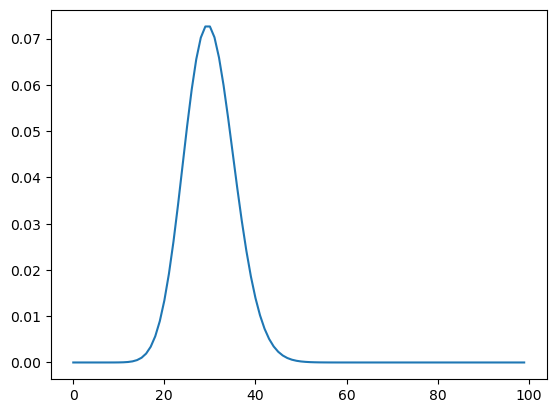

In [19]:
K = [i for i in range(100)]
mu = 30
p = [np.exp(-mu)*mu**k/math.factorial(k) for k in K]
plt.plot(p)

In [2]:
DisplayPlots = True
SaveData = False
RecomputeData = False
Jump = False
AdverseSelection = False
tag = '' #'.jump' '.adverse'
DataFileName = 'Lesson2' + tag + '.dat'
# parameters ------
np.random.seed(10)
ndays = 1
deltat = 1 # seconds
StartDate = dt.datetime(2023,9,15,9,30,0) #fake date
date_list = [StartDate + dt.timedelta(seconds=x * deltat) for x in range(0, int(6.5*3600))]
date_text= [x.strftime('%Y-%m-%d %H:%M:%S') for x in date_list]
n = len(date_list)
DeltaT = n
A = 0.05
s0 = 20.
sigma = s0 * 0.02 / np.sqrt(n)
k = np.log(2.) / 0.01
q0 = 100.
gamma = 1e-2 / q0
theta0 = 0.5
h = 15 * 60
AllDeltas = [0.0025,0.005,0.0075,0.01,0.015,0.02,0.025,0.03,0.035,0.04,0.045,0.05,0.06,0.07,0.08,0.09,0.1,np.inf]
#AllDeltas = [0.0025,np.inf]

In [4]:
def PrintStats(delta0,Stats):
    if np.isinf(delta0):
        print("Av-St, %1.0f, %1.0f, %1.0f,%1.1f"
              % (Stats[delta0]['mu'], Stats[delta0]['sigma'], Stats[delta0]['q_std'],
                 Stats[delta0]['Sharpe']))
    else:
        print("%1.4f, %1.0f, %1.0f, %1.0f,%1.1f"
              % (delta0, Stats[delta0]['mu'], Stats[delta0]['sigma'], Stats[delta0]['q_std'],
                 Stats[delta0]['Sharpe']))

Loading data from file Lesson2.dat...Done.
1/2 spread,mean pnl,std pnl, std q, Sharpe
0.0025, 526, 1217, 3027,0.4
0.0050, 832, 1136, 2876,0.7
0.0075, 1050, 1057, 2610,1.0
0.0100, 1169, 920, 2386,1.3
0.0150, 1231, 814, 1974,1.5
0.0200, 1163, 658, 1730,1.8
0.0250, 1062, 581, 1433,1.8
0.0300, 877, 518, 1204,1.7
0.0350, 722, 417, 1038,1.7
0.0400, 592, 360, 847,1.6
0.0450, 471, 294, 716,1.6
0.0500, 383, 256, 598,1.5
0.0600, 215, 173, 439,1.2
0.0700, 127, 119, 302,1.1
0.0800, 70, 86, 219,0.8
0.0900, 43, 64, 152,0.7
0.1000, 23, 45, 107,0.5
Av-St, 1277, 94, 210,13.6


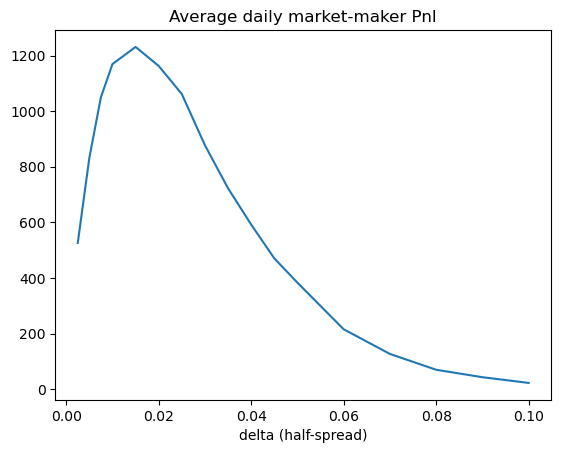

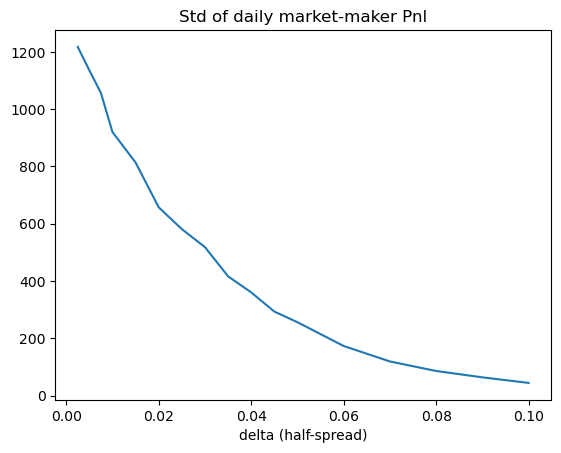

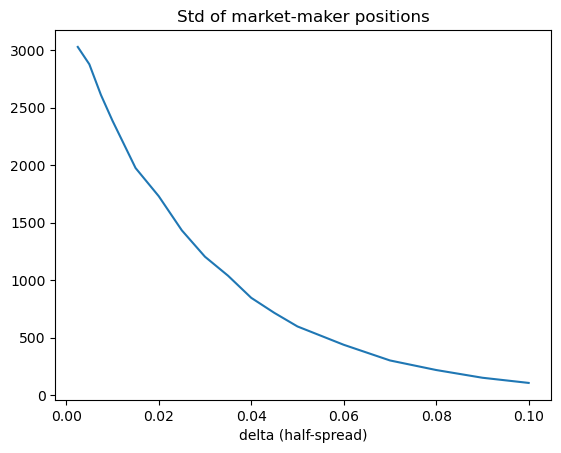

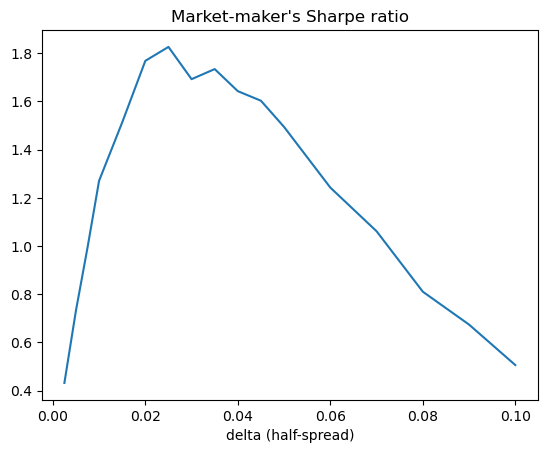

In [5]:
if RecomputeData:
    DailyPnls = {}
    IntradayPnls = {}
    MidPrice = {}
    Pos = {}
    Stats = {}
    print("1/2 spread,mean pnl,std pnl, std q, Sharpe")
    for delta0 in AllDeltas:
        delta_b = None
        delta_a = None
        DailyPnls[delta0] = np.zeros(ndays)
        IntradayPnls[delta0] = np.zeros(n)
        Pos[delta0] = np.zeros(n)
        MidPrice[delta0] = np.zeros(n)
        q_sum_sq = 0.
        q_sum = 0.
        for ind in range(ndays):
            u_b = np.random.uniform(0., 1., n)
            u_a = np.random.uniform(0., 1., n)
            dN_b = np.zeros(n)
            dN_a = np.zeros(n)
            N_b = np.zeros(n)
            N_a = np.zeros(n)
            q = np.zeros(n)
            dW = np.array(np.random.normal(0., 1., n))
            ds = sigma * dW
            # jump
            if Jump:
                s = s0 + np.cumsum(ds)
                ds[int(n/2)] = -0.05 * s[int(n/2)]
            s = s0 + np.cumsum(ds)

            for t in range(1, n):

                if np.isinf(delta0): #Avellaneda-Stoikov model
                    delta_b = max(0.5 * gamma * sigma * sigma * DeltaT + (1. / gamma) * np.log(
                        1. + gamma / k) + gamma * sigma * sigma * DeltaT * q[t - 1], 0.)
                    delta_a = max(0.5 * gamma * sigma * sigma * DeltaT + (1. / gamma) * np.log(
                        1. + gamma / k) - gamma * sigma * sigma * DeltaT * q[t - 1], 0.)
                else: #constant spread model
                    delta_b = delta0
                    delta_a = delta0

                if AdverseSelection:
                    # adverse selection model
                    theta = theta0 * (s[min(t + h, n - 1)] - s[t]) / (sigma * np.sqrt(h))
                    adv_factor = 1. / (1. + np.exp(-theta))
                    lambda_b = A * np.exp(-k * delta_b) * (1. - adv_factor)
                    lambda_a = A * np.exp(-k * delta_a) * adv_factor
                else:
                    lambda_b = A * np.exp(-k * delta_b)
                    lambda_a = A * np.exp(-k * delta_a)

                if u_b[t] < lambda_b * deltat:
                    dN_b[t] = 1.
                else:
                    dN_b[t] = 0.
                if u_a[t] < lambda_a * deltat:
                    dN_a[t] = 1.
                else:
                    dN_a[t] = 0.
                N_b[t] = N_b[t-1] + dN_b[t]
                N_a[t] = N_a[t-1] + dN_a[t]
                q[t] = q0 * (N_b[t] - N_a[t])

            p_b = s - delta_b
            p_a = s + delta_a
            dx = q0 * (np.multiply(p_a,dN_a) - np.multiply(p_b,dN_b))
            x = np.cumsum(dx)
            pnl = x + np.multiply(q,s)

            DailyPnls[delta0][ind] = pnl[-1] #cumulated daily pnl
            IntradayPnls[delta0] = pnl
            Pos[delta0] = q
            MidPrice[delta0] = s
            q_sum_sq += np.sum(np.multiply(q,q))
            q_sum += np.sum(q)
        q_var = (1./(ndays * n)) * q_sum_sq - ((1./(ndays * n))  * q_sum)**2
        Stats[delta0] = {}
        Stats[delta0]['mu'] = np.mean(DailyPnls[delta0])
        Stats[delta0]['sigma'] = np.std(DailyPnls[delta0])
        Stats[delta0]['Sharpe'] = Stats[delta0]['mu'] / Stats[delta0]['sigma']
        Stats[delta0]['q_std'] = np.sqrt(q_var)
        PrintStats(delta0,Stats)
    if SaveData:
        # save data ------------------------------------
        DataToSave = {}
        DataToSave['AllDeltas'] = AllDeltas
        DataToSave['DailyPnls'] = DailyPnls
        DataToSave['IntradayPnls'] = IntradayPnls
        DataToSave['Pos'] = Pos
        DataToSave['MidPrice'] = MidPrice
        DataToSave['Stats'] = Stats
        print("Saving data to file %s..." % (DataFileName), end='')
        file = open(DataFileName, 'wb')
        pickle.dump(DataToSave, file)
        file.close()
        print("done.")
        # -----------------------------------------------
else:
    # load data ------------------------------------
    print("Loading data from file %s..." % (DataFileName), end='')
    file = open(DataFileName, 'rb')
    Data = pickle.load(file)
    file.close()
    print("Done.")
    AllDeltas = Data['AllDeltas']
    DailyPnls = Data['DailyPnls']
    IntradayPnls = Data['IntradayPnls']
    Pos = Data['Pos']
    MidPrice = Data['MidPrice']
    Stats = Data['Stats']
    print("1/2 spread,mean pnl,std pnl, std q, Sharpe")
    for delta0 in AllDeltas:
        PrintStats(delta0, Stats)
    # -----------------------------------------------

if DisplayPlots:
    delta0 = np.inf
    mu_vals = []
    sigma_vals = []
    q_std_vals = []
    Sharpe_vals = []
    for delta in AllDeltas:
        mu_vals.append(Stats[delta]['mu'])
        sigma_vals.append(Stats[delta]['sigma'])
        q_std_vals.append(Stats[delta]['q_std'])
        Sharpe_vals.append(Stats[delta]['Sharpe'])

    '''plt.figure()
    ax = plt.gca()
    ax.ticklabel_format(axis='y', useOffset=False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.plot_date(date_list, MidPrice[delta0], '-')
    plt.title('intraday mid price')

    plt.figure()
    ax = plt.gca()
    ax.ticklabel_format(axis='y', useOffset=False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.plot_date(date_list, Pos[delta0], '-')
    plt.title('intraday stock inventory q_t')

    plt.figure()
    ax = plt.gca()
    ax.ticklabel_format(axis='y', useOffset=False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.plot_date(date_list, IntradayPnls[delta0], '-')
    plt.title('intraday market-maker pnl')'''

    plt.figure()
    plt.plot(AllDeltas, mu_vals, '-')
    plt.xlabel('delta (half-spread)')
    plt.title('Average daily market-maker Pnl')

    plt.figure()
    plt.xlabel('delta (half-spread)')
    plt.plot(AllDeltas, sigma_vals, '-')
    plt.title('Std of daily market-maker Pnl')

    plt.figure()
    plt.xlabel('delta (half-spread)')
    plt.plot(AllDeltas, q_std_vals, '-')
    plt.title('Std of market-maker positions')

    plt.figure()
    plt.xlabel('delta (half-spread)')
    plt.plot(AllDeltas, Sharpe_vals, '-')
    plt.title('Market-maker\'s Sharpe ratio')

    plt.show()